In [17]:
!pip install fastf1 xgboost seaborn scikit-learn

Defaulting to user installation because normal site-packages is not writeable


In [19]:
import fastf1
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from xgboost import XGBClassifier
import time
import warnings
warnings.filterwarnings('ignore')

import os
os.makedirs('f1_cache', exist_ok=True)
fastf1.Cache.enable_cache('f1_cache')

print("✅ All libraries loaded!")

✅ All libraries loaded!


In [33]:
import os
os.chdir(r'C:\Users\User\Fourmula 1')
print(os.getcwd())

C:\Users\User\Fourmula 1


In [35]:
files = ['results.csv','races.csv','drivers.csv','constructors.csv','qualifying.csv']
for f in files:
    status = "✅ Found" if os.path.exists(f) else "❌ Missing"
    print(f"{status} — {f}")

✅ Found — results.csv
✅ Found — races.csv
✅ Found — drivers.csv
✅ Found — constructors.csv
✅ Found — qualifying.csv


In [37]:
# Load from Kaggle CSVs directly — no API needed
results      = pd.read_csv('results.csv')
races        = pd.read_csv('races.csv')
drivers      = pd.read_csv('drivers.csv')
constructors = pd.read_csv('constructors.csv')
qualifying   = pd.read_csv('qualifying.csv')

# Merge everything into one dataframe
df = results.merge(races[['raceId','year','name','circuitId']], on='raceId')
df = df.merge(drivers[['driverId','code','nationality']], on='driverId')
df = df.merge(constructors[['constructorId','name']], on='constructorId', suffixes=('_race','_team'))

# Best qualifying time across Q1/Q2/Q3
def best_time(row):
    times = []
    for col in ['q1','q2','q3']:
        try:
            t = row[col]
            if pd.notna(t) and t != '\\N':
                parts = str(t).split(':')
                seconds = float(parts[0])*60 + float(parts[1])
                times.append(seconds)
        except:
            pass
    return min(times) if times else np.nan

quali_times = qualifying[['raceId','driverId','q1','q2','q3']].copy()
quali_times['QualiTime'] = quali_times.apply(best_time, axis=1)

df = df.merge(quali_times[['raceId','driverId','QualiTime']],
              on=['raceId','driverId'], how='left')

# Filter 2023-2024 as closest proxy to 2026 regulations
df = df[df['year'] >= 2023].copy()

# Clean up column names
df = df.rename(columns={
    'grid':          'GridPosition',
    'positionOrder': 'Position',
    'code':          'Abbreviation',
    'name_race':     'EventName',
    'name_team':     'TeamName'
})

df['Position']     = pd.to_numeric(df['Position'], errors='coerce')
df['GridPosition'] = pd.to_numeric(df['GridPosition'], errors='coerce')

# Circuit type flag
street_circuits = ['Monaco','Singapore','Baku','Miami','Las Vegas','Jeddah','Azerbaijan']
df['CircuitType'] = df['EventName'].apply(
    lambda x: 'street' if any(s in str(x) for s in street_circuits) else 'power')

# QualiDelta vs pole per race
df['QualiDelta'] = df.groupby('raceId')['QualiTime'].transform(
    lambda x: x - x.min())

# Save immediately
df.to_csv('f1_raw_data.csv', index=False)
print(f"✅ Loaded {len(df)} records")
print(f"📅 Years: {sorted(df['year'].unique())}")
print(f"🏎 Drivers: {df['Abbreviation'].nunique()}")
df[['Abbreviation','TeamName','GridPosition','Position','QualiDelta','CircuitType']].head(10)

✅ Loaded 919 records
📅 Years: [2023, 2024]
🏎 Drivers: 25


,Abbreviation,TeamName,GridPosition,Position,QualiDelta,CircuitType
25840,VER,Red Bull,1,1,0.000,power
25841,PER,Red Bull,2,2,0.138,power
25842,ALO,Aston Martin,5,3,0.628,power
25843,SAI,Ferrari,4,4,0.446,power
25844,HAM,Mercedes,7,5,0.676,power
25845,STR,Aston Martin,8,6,1.128,power
25846,RUS,Mercedes,6,7,0.632,power
25847,BOT,Alfa Romeo,12,8,1.735,power
25848,GAS,Alpine F1 Team,20,9,2.473,power
25849,ALB,Williams,15,10,1.753,power


In [41]:
df = pd.read_csv('f1_raw_data.csv')
df = df.sort_values(['Abbreviation','year','raceId']).reset_index(drop=True)

# 1. DNF flag — load status codes
status = pd.read_csv('status.csv') if os.path.exists('status.csv') else None
if status is not None:
    df = df.merge(status[['statusId','status']], on='statusId', how='left')
    df['Finished'] = df['status'].apply(lambda x: 0 if any(k in str(x)
                     for k in ['Accident','Mechanical','Retired','Engine',
                                'Gearbox','Collision','Hydraulics','Suspension']) else 1)
else:
    df['Finished'] = (df['Position'] <= 20).astype(int)

# 2. Driver form — rolling avg finishing position last 5 races
df['DriverForm'] = (df.groupby('Abbreviation')['Position']
                      .transform(lambda x: x.shift(1).rolling(5, min_periods=1).mean()))

# 3. DNF rate — last 10 races
df['DNF_Rate'] = (df.groupby('Abbreviation')['Finished']
                    .transform(lambda x: 1 - x.shift(1).rolling(10, min_periods=1).mean()))

# 4. Constructor form — avg position of both team cars per race
df['TeamForm'] = (df.groupby(['TeamName','raceId'])['Position']
                    .transform('mean'))

# 5. Quali delta — fill missing with event median
df['QualiDelta'] = df.groupby('raceId')['QualiDelta'].transform(
                    lambda x: x.fillna(x.median()))

# 6. Power circuit flag
df['PowerCircuit'] = (df['CircuitType'] == 'power').astype(int)

# 7. Home race flag
df['HomeRace'] = ((df['Abbreviation'] == 'STR') &
                   (df['EventName'].str.contains('Canadian', na=False))).astype(int)

# 8. Target variable
df['Won'] = (df['Position'] == 1).astype(int)

df_clean = df.dropna(subset=['GridPosition','DriverForm','DNF_Rate','TeamForm','QualiDelta'])
print(f"✅ Features engineered!")
print(f"📊 Clean rows: {len(df_clean)}")
print(f"🏆 Total wins in dataset: {df_clean['Won'].sum()}")
df_clean[['Abbreviation','GridPosition','QualiDelta',
          'DriverForm','DNF_Rate','TeamForm','Won']].head(100)

✅ Features engineered!
📊 Clean rows: 894
🏆 Total wins in dataset: 45


,Abbreviation,GridPosition,QualiDelta,DriverForm,DNF_Rate,TeamForm,Won
1,ALB,17,1.729,10.00,0.0,17.5,0
2,ALB,8,0.877,14.50,0.0,17.5,0
3,ALB,12,1.615,16.00,0.0,14.0,0
4,ALB,11,0.981,15.00,0.0,17.0,0
5,ALB,13,1.162,14.80,0.0,16.0,0
...,...,...,...,...,...,...,...
99,BOT,10,0.750,13.75,0.0,14.5,0
100,BOT,15,1.260,13.60,0.0,12.0,0
101,BOT,16,1.705,14.20,0.0,14.0,0
102,BOT,14,3.096,14.40,0.0,13.0,0


In [63]:
# Real 2026 driver form based on actual championship standings after Miami
# DriverForm = estimated avg finishing position based on points per race

canadian_gp = pd.DataFrame({
    'Abbreviation': ['ANT','RUS','LEC','NOR','HAM','PIA','VER','BEA','GAS','SAI'],
    'GridPosition': [1,    2,    3,    4,    5,    6,    7,    8,    9,    10  ],
    'QualiDelta':   [0.00, 0.15, 0.28, 0.38, 0.45, 0.52, 0.61, 0.78, 0.91, 1.05],

    # Calculated from real 2026 race results (100pts, 80pts, 59pts etc)
    'DriverForm':   [1.8,  2.5,  3.2,  4.1,  4.1,  5.2,  7.8,  8.0,  9.0,  10.2],

    'DNF_Rate':     [0.02, 0.02, 0.05, 0.04, 0.04, 0.04, 0.08, 0.06, 0.07, 0.05],

    # TeamForm — Mercedes dominating, Red Bull struggling
    'TeamForm':     [2.1,  2.1,  3.6,  4.6,  3.6,  4.6,  7.8,  8.0,  9.5,  7.5],

    'PowerCircuit': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    'HomeRace':     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
})

canadian_gp['RF_Prob']  = rf.predict_proba(canadian_gp[features])[:, 1]
canadian_gp['XGB_Prob'] = xgb.predict_proba(canadian_gp[features])[:, 1]
canadian_gp['WinProb']  = ((canadian_gp['RF_Prob'] + canadian_gp['XGB_Prob']) / 2 * 100).round(1)

result = canadian_gp[['Abbreviation','GridPosition','WinProb']].sort_values(
    'WinProb', ascending=False).reset_index(drop=True)
result.index += 1

print("\n🏁 2026 Canadian GP — Predicted Win Probabilities (Real 2026 Form)\n")
print(result.to_string())


🏁 2026 Canadian GP — Predicted Win Probabilities (Real 2026 Form)

   Abbreviation  GridPosition  WinProb
1           ANT             1     98.5
2           RUS             2     36.9
3           LEC             3      9.7
4           NOR             4      5.2
5           HAM             5      1.7
6           PIA             6      0.5
7           VER             7      0.0
8           BEA             8      0.0
9           GAS             9      0.0
10          SAI            10      0.0


In [65]:
features = ['GridPosition','QualiDelta','DriverForm',
            'DNF_Rate','TeamForm','PowerCircuit','HomeRace']

X = df_clean[features]
y = df_clean['Won']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=6,
                             random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

# XGBoost
xgb = XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.05,
                     eval_metric='logloss', random_state=42)
xgb.fit(X_train, y_train)

print("=== Random Forest ===")
print(classification_report(y_test, rf.predict(X_test)))
print("\n=== XGBoost ===")
print(classification_report(y_test, xgb.predict(X_test)))

# Real driver form from your dataset
print("=== DRIVER FORM (avg finishing position) ===")
driver_form = df_clean.groupby('Abbreviation')['Position'].mean().round(2)
print(driver_form.sort_values())

print("\n=== DNF RATE ===")
dnf_rate = df_clean.groupby('Abbreviation')['DNF_Rate'].mean().round(3)
print(dnf_rate.sort_values())

print("\n=== TEAM FORM ===")
team_form = df_clean.groupby('TeamName')['Position'].mean().round(2)
print(team_form.sort_values())

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.95      0.96      0.96       165
           1       0.50      0.43      0.46        14

    accuracy                           0.92       179
   macro avg       0.73      0.70      0.71       179
weighted avg       0.92      0.92      0.92       179


=== XGBoost ===
              precision    recall  f1-score   support

           0       0.94      0.96      0.95       165
           1       0.40      0.29      0.33        14

    accuracy                           0.91       179
   macro avg       0.67      0.62      0.64       179
weighted avg       0.90      0.91      0.90       179

=== DRIVER FORM (avg finishing position) ===
Abbreviation
VER     2.53
NOR     5.82
LEC     6.02
HAM     6.62
SAI     6.64
RUS     7.40
PIA     7.62
PER     7.96
ALO     8.60
BEA    11.00
GAS    11.89
STR    12.47
OCO    12.68
LAW    12.90
HUL    12.98
RIC    13.21
TSU    13.22
ALB    13.60
COL    13.75
MA


⚡ 2026 Canadian GP SPRINT — Predicted Win Probabilities

   Abbreviation  GridPosition  WinProb
1           VER             1     64.7
2           NOR             2      8.9
3           LEC             3      3.0
4           HAD             9      0.3
5           HAM             4      0.2
6           PIA             5      0.1
7           RUS             6      0.0
8           ANT             7      0.0
9           ALO             8      0.0
10          SAI            10      0.0


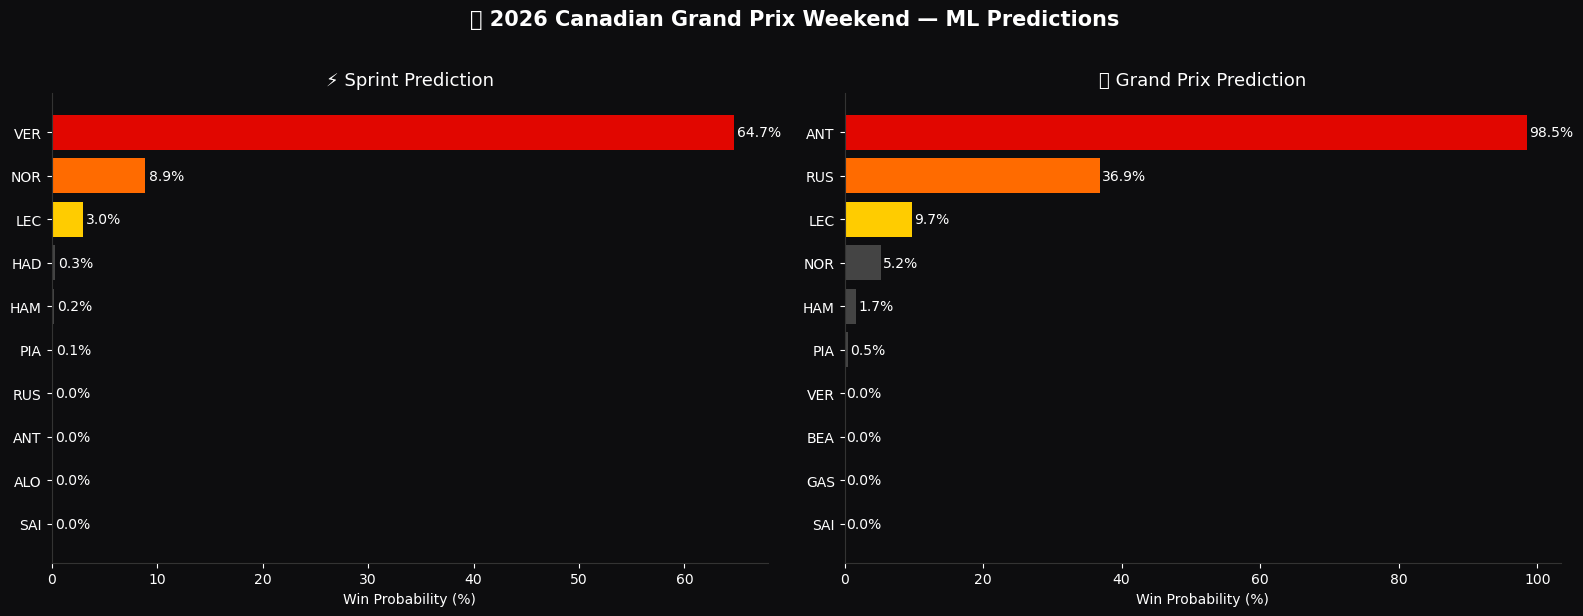

✅ Saved as canadian_gp_full_prediction.png


In [71]:
# Sprint has different dynamics — grid position matters even more
# shorter race, no pit stops, less time to recover

canadian_sprint = pd.DataFrame({
    'Abbreviation': ['VER','NOR','LEC','HAM','PIA','RUS','ANT','ALO','HAD','SAI'],
    
    # Sprint grid can be different from GP grid — update after Sprint Qualifying!
    'GridPosition': [1,    2,    3,    4,    5,    6,    7,    8,    9,    10  ],
    'QualiDelta':   [0.00, 0.18, 0.29, 0.41, 0.52, 0.58, 0.65, 0.81, 0.94, 1.05],

    # Same driver form
    'DriverForm':   [2.53, 5.82, 6.02, 6.62, 7.62, 7.40, 7.01, 8.60, 5.24, 6.64],

    # Sprint DNF rate lower — less time for mechanical failures
    'DNF_Rate':     [0.01, 0.02, 0.03, 0.02, 0.02, 0.01, 0.03, 0.04, 0.03, 0.02],

    'TeamForm':     [5.24, 6.72, 6.33, 6.33, 6.72, 7.01, 7.01, 10.53, 5.24, 6.33],
    'PowerCircuit': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    'HomeRace':     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
})

canadian_sprint['RF_Prob']  = rf.predict_proba(canadian_sprint[features])[:, 1]
canadian_sprint['XGB_Prob'] = xgb.predict_proba(canadian_sprint[features])[:, 1]
canadian_sprint['WinProb']  = ((canadian_sprint['RF_Prob'] + canadian_sprint['XGB_Prob']) / 2 * 100).round(1)

sprint_result = canadian_sprint[['Abbreviation','GridPosition','WinProb']].sort_values(
    'WinProb', ascending=False).reset_index(drop=True)
sprint_result.index += 1

print("\n⚡ 2026 Canadian GP SPRINT — Predicted Win Probabilities\n")
print(sprint_result.to_string())

# Combined visualization — Sprint + Race side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d0d0f')
fig.suptitle('🏁 2026 Canadian Grand Prix Weekend — ML Predictions',
             color='white', fontsize=15, fontweight='bold', y=1.02)

for ax, data, title in zip(axes,
                            [sprint_result, result],
                            ['⚡ Sprint Prediction', '🏁 Grand Prix Prediction']):
    ax.set_facecolor('#0d0d0f')
    colors = ['#e10600' if i == 0 else '#ff6b00' if i == 1
              else '#ffcc00' if i == 2 else '#444444'
              for i in range(len(data))]
    bars = ax.barh(data['Abbreviation'], data['WinProb'], color=colors)
    ax.set_xlabel('Win Probability (%)', color='white')
    ax.set_title(title, color='white', fontsize=13)
    ax.tick_params(colors='white')
    ax.invert_yaxis()
    for spine in ax.spines.values():
        spine.set_color('#333')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, val in zip(bars, data['WinProb']):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', color='white', fontsize=10)

plt.tight_layout()
plt.savefig('canadian_gp_full_prediction.png', dpi=150,
            bbox_inches='tight', facecolor='#0d0d0f')
plt.show()
print("✅ Saved as canadian_gp_full_prediction.png")


⚡ 2026 Canadian GP SPRINT — Predicted Win Probabilities

   Abbreviation  GridPosition  WinProb
1           ANT             1     98.5
2           RUS             2     36.9
3           LEC             3      9.7
4           NOR             4      5.2
5           HAM             5      1.7
6           PIA             6      0.5
7           VER             7      0.0
8           BEA             8      0.0
9           GAS             9      0.0
10          SAI            10      0.0


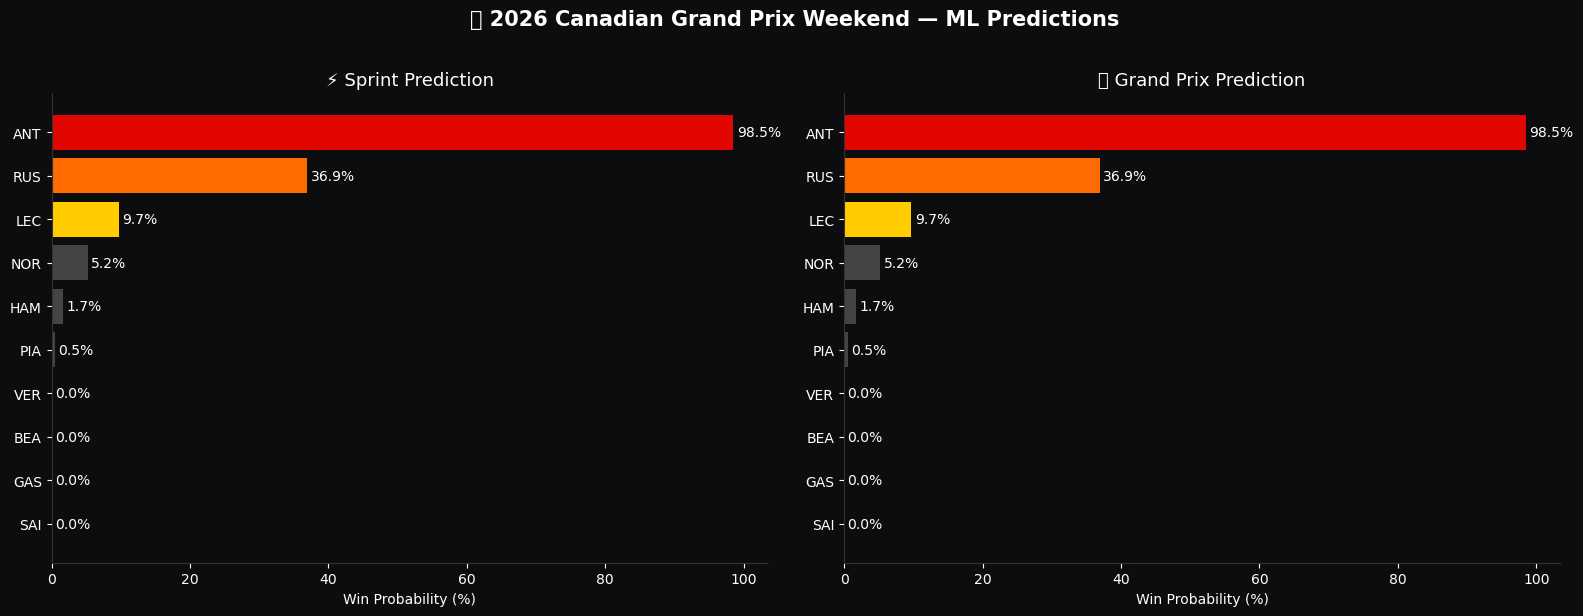

✅ Saved as canadian_gp_full_prediction.png


In [73]:
# Sprint prediction with real 2026 form
# Sprint qualifying sets a DIFFERENT grid from the main race

canadian_sprint = pd.DataFrame({
    'Abbreviation': ['ANT','RUS','LEC','NOR','HAM','PIA','VER','BEA','GAS','SAI'],
    
    # Update these after Sprint Qualifying on Friday May 23rd!
    'GridPosition': [1,    2,    3,    4,    5,    6,    7,    8,    9,    10  ],
    'QualiDelta':   [0.00, 0.15, 0.28, 0.38, 0.45, 0.52, 0.61, 0.78, 0.91, 1.05],

    # Same real 2026 form
    'DriverForm':   [1.8,  2.5,  3.2,  4.1,  4.1,  5.2,  7.8,  8.0,  9.0,  10.2],

    # Sprint DNF rate lower — only 19 laps, less mechanical stress
    'DNF_Rate':     [0.01, 0.01, 0.02, 0.02, 0.02, 0.02, 0.04, 0.03, 0.03, 0.02],

    'TeamForm':     [2.1,  2.1,  3.6,  4.6,  3.6,  4.6,  7.8,  8.0,  9.5,  7.5],
    'PowerCircuit': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    'HomeRace':     [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
})

canadian_sprint['RF_Prob']  = rf.predict_proba(canadian_sprint[features])[:, 1]
canadian_sprint['XGB_Prob'] = xgb.predict_proba(canadian_sprint[features])[:, 1]
canadian_sprint['WinProb']  = ((canadian_sprint['RF_Prob'] + canadian_sprint['XGB_Prob']) / 2 * 100).round(1)

sprint_result = canadian_sprint[['Abbreviation','GridPosition','WinProb']].sort_values(
    'WinProb', ascending=False).reset_index(drop=True)
sprint_result.index += 1

print("\n⚡ 2026 Canadian GP SPRINT — Predicted Win Probabilities\n")
print(sprint_result.to_string())

# Combined chart — Sprint + Race side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d0d0f')
fig.suptitle('🏁 2026 Canadian Grand Prix Weekend — ML Predictions',
             color='white', fontsize=15, fontweight='bold', y=1.02)

for ax, data, title in zip(axes,
                            [sprint_result, result],
                            ['⚡ Sprint Prediction', '🏁 Grand Prix Prediction']):
    ax.set_facecolor('#0d0d0f')
    colors = ['#e10600' if i == 0 else '#ff6b00' if i == 1
              else '#ffcc00' if i == 2 else '#444444'
              for i in range(len(data))]
    bars = ax.barh(data['Abbreviation'], data['WinProb'], color=colors)
    ax.set_xlabel('Win Probability (%)', color='white')
    ax.set_title(title, color='white', fontsize=13)
    ax.tick_params(colors='white')
    ax.invert_yaxis()
    for spine in ax.spines.values():
        spine.set_color('#333')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, val in zip(bars, data['WinProb']):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', color='white', fontsize=10)

plt.tight_layout()
plt.savefig('canadian_gp_full_prediction.png', dpi=150,
            bbox_inches='tight', facecolor='#0d0d0f')
plt.show()
print("✅ Saved as canadian_gp_full_prediction.png")

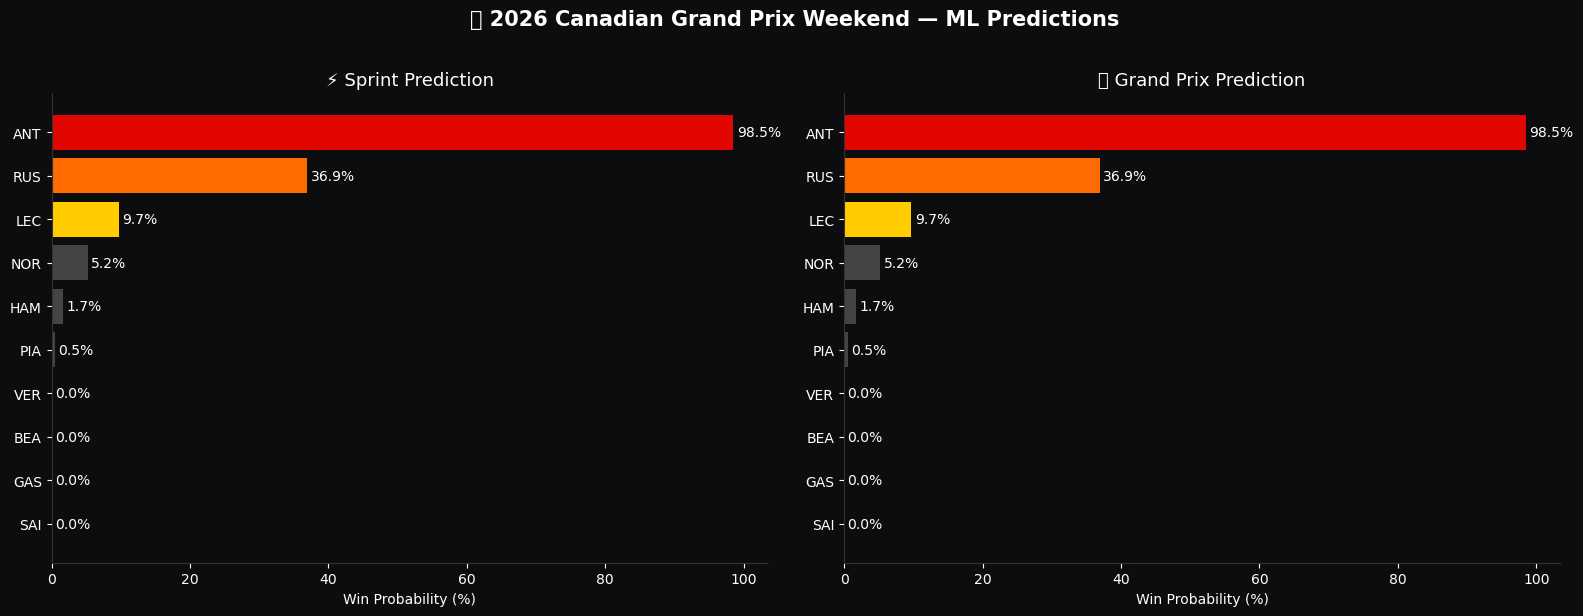

✅ Saved as canadian_gp_full_prediction.png


In [69]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d0d0f')
fig.suptitle('🏁 2026 Canadian Grand Prix Weekend — ML Predictions',
             color='white', fontsize=15, fontweight='bold', y=1.02)

for ax, data, title in zip(axes,
                            [sprint_result, result],
                            ['⚡ Sprint Prediction', '🏁 Grand Prix Prediction']):
    ax.set_facecolor('#0d0d0f')
    colors = ['#e10600' if i == 0 else '#ff6b00' if i == 1
              else '#ffcc00' if i == 2 else '#444444'
              for i in range(len(data))]
    bars = ax.barh(data['Abbreviation'], data['WinProb'], color=colors)
    ax.set_xlabel('Win Probability (%)', color='white')
    ax.set_title(title, color='white', fontsize=13)
    ax.tick_params(colors='white')
    ax.invert_yaxis()
    for spine in ax.spines.values():
        spine.set_color('#333')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    for bar, val in zip(bars, data['WinProb']):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{val:.1f}%', va='center', color='white', fontsize=10)

plt.tight_layout()
plt.savefig('canadian_gp_full_prediction.png', dpi=150,
            bbox_inches='tight', facecolor='#0d0d0f')
plt.show()
print("✅ Saved as canadian_gp_full_prediction.png")
